# End-to-End Multimodal Detection of Lunar and Martian Lava Tubes

In [14]:
import pandas as pd
import pygmt
import xarray as xr
import os
import numpy as np
import json
from utils import *

THARSIS_REGION = [210, 300, -30, 60]
cache_file = "data/mars_relief_cache.nc"
region_file = "data/mars_relief_cache_region.json"


## Cave Catalog

In [15]:
cave_catalog = pd.read_csv("data/Mars_Extended_Cave_Catalog.csv")
cave_catalog

,label,longitude,latitude,TypeCode,Priority,APC_Diameter,APC_Depth,Comment,elevation
0,APC001,240.4585,-0.94678,APC,1,25,32.0,APC -- tiny ~25m,5845.516289
1,APC003,237.6960,-12.47266,APC,1,30,47.0,APC 40m small deep nochain--big smrp?,10500.439389
2,APC005,240.8867,-5.68445,APC,1,30,17.0,APC deep pair,10144.570834
3,APC006,240.9421,-1.61377,APC,1,40,38.0,APC small deep?,6446.123804
4,APC007,241.2993,-1.68555,APC,1,40,28.0,"APC, deep? ~40m",6610.563531
...,...,...,...,...,...,...,...,...,...
1057,CC0926,161.1272,9.64587,crk,0,NaN,NaN,Cerberus fractures in HiRISE,-2767.424452
1058,CC0927,141.3146,30.56317,irr,0,NaN,NaN,Irregular surface hole,-1519.403413
1059,CC0928,141.3121,30.58740,crk,0,NaN,NaN,Small ambiguous hole in fracture,-1559.675572
1060,CC0929,242.9741,-0.26598,sky,1,NaN,NaN,"pair of 60-m pits in flow, 1km apart",6403.049279


In [16]:
cave_catalog = cave_catalog[cave_catalog["Priority"] == 0]
cave_catalog

,label,longitude,latitude,TypeCode,Priority,APC_Diameter,APC_Depth,Comment,elevation
13,APC016,243.0341,-4.20642,APC,0,55,35.0,APC - deep - 60m >.65 d/D,8027.260543
37,APC045,237.8282,-2.04173,APC,0,95,67.0,Probably Type I,4971.375411
53,APC061,240.9015,-7.17221,APC,0,119,55.0,APC nochain,12331.801712
65,APC073,245.8900,-16.33000,APC,0,150,50.0,APC,6285.005344
66,APC074,239.2200,-13.94000,APC,0,180,46.0,APC,9509.232576
...,...,...,...,...,...,...,...,...,...
1055,CC0924,161.1229,9.64621,crk,0,NaN,NaN,Cerberus fractures in HiRISE,-2769.863844
1056,CC0925,161.1371,9.64560,crk,0,NaN,NaN,Cerberus fractures in HiRISE,-2773.076374
1057,CC0926,161.1272,9.64587,crk,0,NaN,NaN,Cerberus fractures in HiRISE,-2767.424452
1058,CC0927,141.3146,30.56317,irr,0,NaN,NaN,Irregular surface hole,-1519.403413


## Exposed Ice

In [17]:
exposed_ice = pd.read_csv("data/impact_exposed_ice.csv")

# only select regions where ice is (at least) probably there
exposed_ice = exposed_ice[(exposed_ice["ice_exposure"] == "Yes") | (exposed_ice["ice_exposure"] == "Probable")]
exposed_ice

,site_id,latitude,longitude,ice_exposure,d_icy,d_nonicy,reference,crism_ice,notes,color,image
3,Site P7,57.24,358.02,Probable,x,1.75,ESP_037069_2375,x,One 1.5-m crater has an anomalous relatively-b...,#FFFF00,https://www.uahirise.org/ESP_037069_2375
4,Site P9,75.42,57.24,Probable,x,Uncertain,ESP_044992_2555,x,Multiple follow-on images show widespread brig...,#FFFF00,https://www.uahirise.org/ESP_044992_2555
6,Site P11,63.82,26.07,Probable,x,2,ESP_046378_2440,x,Relatively-blue glint that later faded. Classi...,#FFFF00,https://www.uahirise.org/ESP_046378_2440
7,Site P12,-42.58,226.83,Probable,x,5.5,ESP_049061_1370,x,Slight color anomaly. Later faded but not dist...,#FFFF00,https://www.uahirise.org/ESP_049061_1370
14,Site P20,71.15,94.14,Probable,x,Uncertain,ESP_053100_2515,x,Relatively-blue patches approximately match lo...,#FFFF00,https://www.uahirise.org/ESP_053100_2515
22,Site P28,-81.49,41.35,Probable,x,18,ESP_057152_0985,x,Impacted seasonal frost on south polar layered...,#FFFF00,https://www.uahirise.org/ESP_057152_0985
23,Site 1,46.35,176.89,Yes,4;3.75,4.5,PSP_009978_2265,n,x,#00FFC5,https://www.uahirise.org/PSP_009978_2265
24,Site 2,43.30,164.21,Yes,6,2.5,PSP_010084_2235,n,x,#00FFC5,https://www.uahirise.org/PSP_010084_2235
25,Site 3,55.58,150.60,Yes,8;4.5;3.5;3;3;3;1,x,PSP_010625_2360,y,x,#00FFC5,https://www.uahirise.org/PSP_010625_2360
26,Site 4,45.07,164.70,Yes,4.5,4,PSP_010585_2255,n,x,#00FFC5,https://www.uahirise.org/PSP_010585_2255


## Landing Sites

In [18]:
landing_sites = pd.read_csv("data/landing_sites.csv")
landing_sites

,longitude,latitude,mission
0,137.441700,-4.589500,MSL
1,135.623447,4.502000,InSight
2,-5.526600,-1.946000,Opportunity
3,175.478480,-14.572000,Spirit
4,-33.550000,19.330000,Pathfinder
5,-125.749222,68.219000,Phoenix
6,134.280900,47.667300,Viking 2
7,-47.950000,22.270000,Viking 1
8,77.450886,18.444627,M2020
9,110.318000,24.748000,Tianwen-1


## Priority Zones
Due to presence of subsurface ice

In [19]:
mars_radar_targeting_zones = pd.read_json("data/mars_radar_targeting_zones.json")
mars_radar_targeting_zones

,shape_length,shape_area,coordinates
0,5.843385e+07,21416293727900,"[[-179.999448, 36.251544], [-179.977833, 36.27..."
1,5.843385e+07,21416293727900,"[[-41.323617, -61.089205], [-43.348089, -61.08..."
2,5.843385e+07,21416293727900,"[[82.273909, -23.878042999999998], [84.553531,..."
3,5.843385e+07,21416293727900,"[[179.99954, 22.755546], [179.941932, 22.71595..."


## Plot

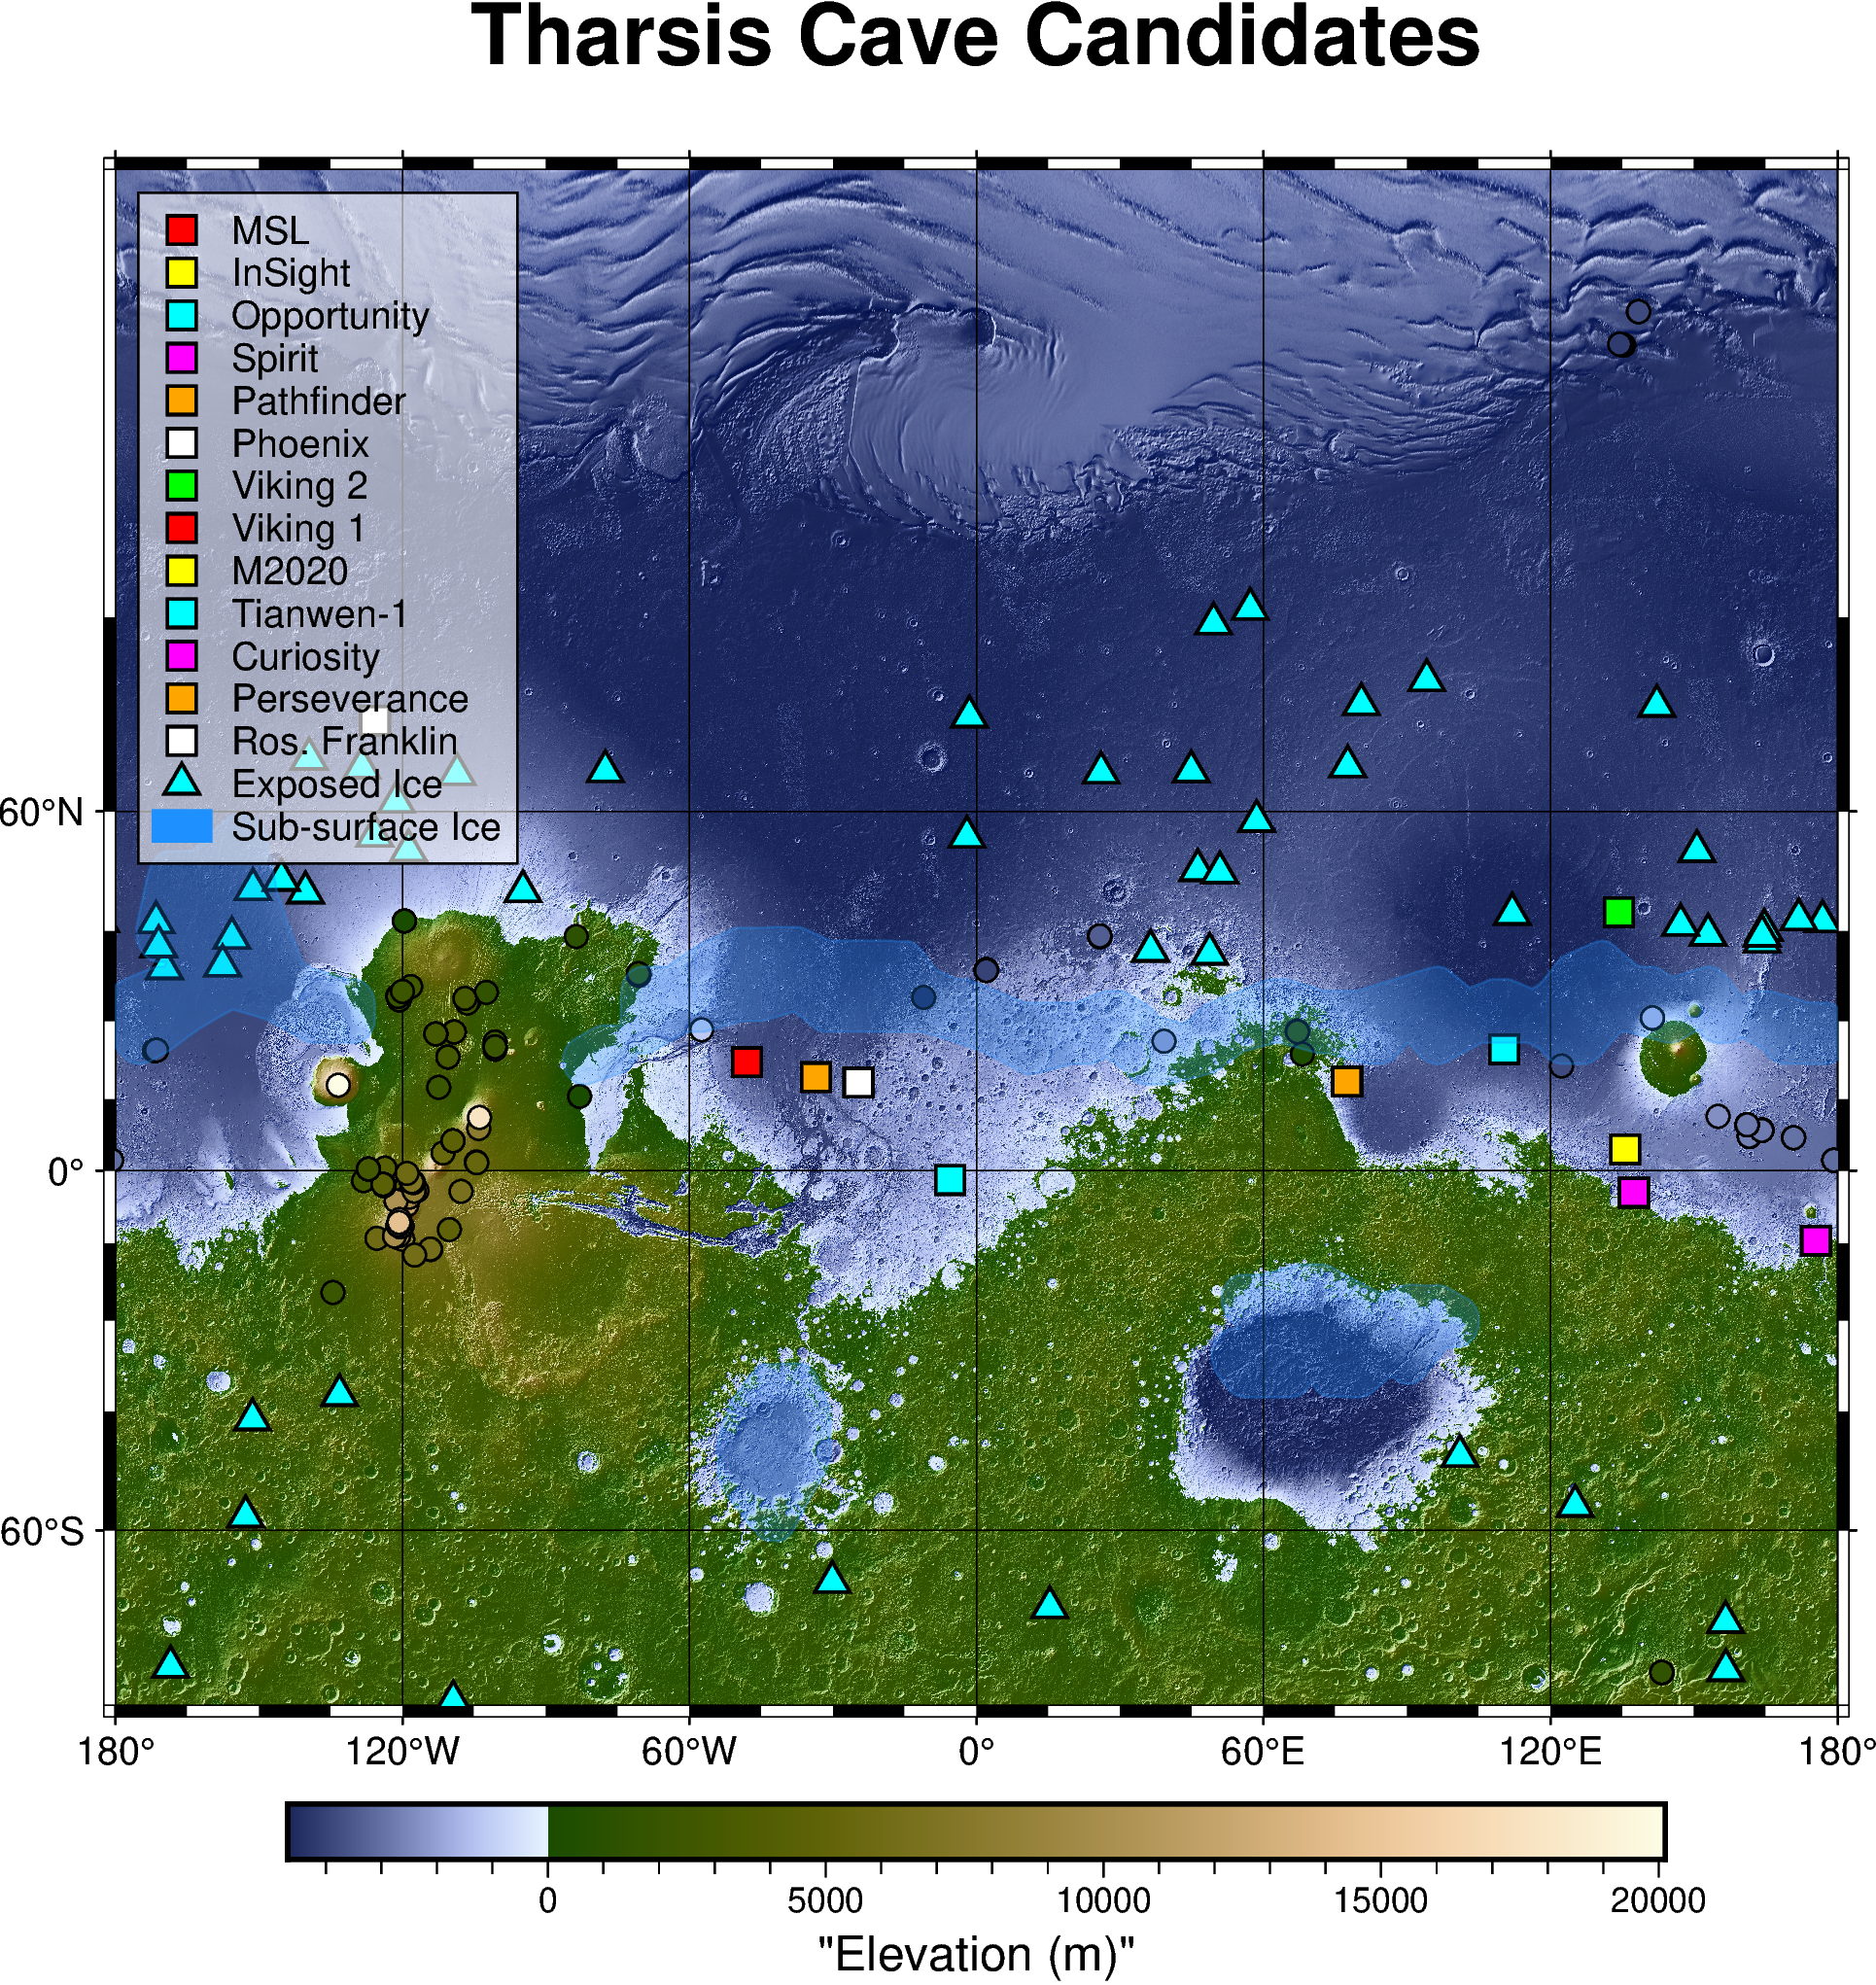

In [21]:
# 1. Prepare coordinates for a 0-centered plot (shift 180–360 → -180–0)
cave_catalog['lon_plot'] = cave_catalog['longitude'].apply(lambda x: x if x <= 180 else x - 360)
landing_sites['lon_plot'] = landing_sites['longitude'].apply(lambda x: x if x <= 180 else x - 360)

data_region = [
    max(min(cave_catalog.lon_plot.min(), landing_sites.lon_plot.min(), min(all_lons)) - 2, -180),
    min(max(cave_catalog.lon_plot.max(), landing_sites.lon_plot.max(), max(all_lons)) + 2,  180),
    max(min(cave_catalog.latitude.min(), landing_sites.latitude.min(), min(all_lats)) - 2,  -90),
    min(max(cave_catalog.latitude.max(), landing_sites.latitude.max(), max(all_lats)) + 2,   90),
]

# 3. Load background relief
if os.path.exists(cache_file) and not region_changed(data_region, region_file):
    print("loading cached data")
    grid = xr.load_dataarray(cache_file, engine="netcdf4")
else:
    print("Downloading data")
    grid = pygmt.datasets.load_mars_relief(resolution="01m", region=data_region)
    grid.to_netcdf(cache_file, engine="netcdf4")
    with open(region_file, "w") as f:
        json.dump(data_region, f)

# 4. Initialize the Figure
fig = pygmt.Figure()

# Color palette for cave elevation
pygmt.makecpt(
    cmap="oleron",
    series=[cave_catalog.elevation.min(), cave_catalog.elevation.max()]
)

# 5. Plot the background terrain
fig.grdimage(
    grid=grid,
    region=data_region,
    projection="M0/15c",
    shading=True,
    frame=["afg", "WSne+tTharsis Cave Candidates"]
)

# 6. Plot the lava tubes
fig.plot(
    x=cave_catalog.lon_plot,
    y=cave_catalog.latitude,
    fill=cave_catalog.elevation,
    cmap=True,
    style="c0.2c",
    pen="0.5p,black",
)

# 7. Plot landing sites — one call per mission for individual legend entries
# Define a color palette (extend as needed)
colors = ["red", "yellow", "cyan", "magenta", "orange", "white", "green"]

missions = landing_sites['mission'].unique()
for i, mission in enumerate(missions):
    subset = landing_sites[landing_sites['mission'] == mission]
    color = colors[i % len(colors)]
    fig.plot(
        x=subset.lon_plot,
        y=subset.latitude,
        style="s0.35c",           # squares to visually distinguish from caves
        fill=color,
        pen="0.8p,black",
        label=mission,
)

# Plot surface ice position
exposed_ice['lon_plot'] = exposed_ice['longitude'].apply(lambda x: x if x <= 180 else x - 360)
fig.plot(
    x=exposed_ice.lon_plot,
    y=exposed_ice.latitude,
    style="t0.35c",   # triangles (distinct from circles and squares)
    fill="cyan",
    pen="0.8p,black",
    label="Exposed Ice",
)

# plot sub-surface ice position
for i, row in mars_radar_targeting_zones.iterrows():
    coords = row["coordinates"]
    lons = [c[0] for c in coords]
    lats = [c[1] for c in coords]

    fig.plot(
        x=lons,
        y=lats,
        fill="dodgerblue",
        pen="0.5p,dodgerblue",
        transparency=75,        # 75% transparent
        close=True,             # close the polygon
        label="Sub-surface Ice" if i == 0 else None,  # legend entry only once
    )

# 8. Add legend
fig.legend(
    position="JTL+jTL+o0.2c",
    box="+gwhite@40+p0.5p,black"
)

# 9. Add colorbar for cave elevation and display
fig.colorbar(frame='af+l"Elevation (m)"')
fig.show()